# Study · Is the documented temperature compensation good for the prediction system?

**Question.** Notebook 00 subtracts a fixed thermal correction from the inclinometer
signal before anything else sees it:

$$ I_{\text{comp}}(t) = I(t) - \big(T_{\text{air}}(t) - T_{\text{air}}(t_0)\big)\cdot c \cdot 1000,
   \qquad c = 0.005 $$

that is, 5 mdeg per °C, applied instantaneously, driven by the station's own air
temperature. This study asks whether that step helps or hurts a forecasting model
built on the signal.

**Why it is in question.** The manufacturer documentation
(`docs/docs-manufacturer/`) gives no thermal coefficient at all. The SEIKA SB1U
already performs temperature drift compensation in hardware, and the only numeric
temperature figure in the whole document set is 20 ppm/K on the reference voltage —
roughly 0.1 mdeg/°C, some fifty times smaller than the correction being applied.
Whatever the correction removes is therefore not instrument drift. It is the
structure's own thermal response, which is exactly the quantity the grey-box model
exists to identify.

**The physical hypothesis, and why "instantaneous" is a defect.** The correction
assumes the structure responds to air temperature at the instant it is measured. The
mechanism says otherwise. Solar radiation heats the exposed face of the wall; the
heat diffuses into a large masonry mass; the resulting differential expansion between
the exposed face and the restrained, embanked face tilts the structure. A body with
thermal mass cannot respond instantaneously to anything. The instantaneous form is
therefore a property of the correction, not of the wall, and the lag structure has to
be **measured** rather than assumed — including the possibility that the true forcing
is solar radiation, with air temperature standing in as its proxy wherever the
radiometer does not exist.

**Sampling.** Every environmental proxy the pipeline aligns against is published
hourly, so the record is aggregated from its native 20-minute rate to one hour
immediately after parsing and every result below is computed on the hourly grid. The
native record is kept alongside for one purpose only: a sub-hourly check on the lag
structure, which an hourly grid cannot resolve.

**Design.** All work is done on station 02 in the current instrument era, the only
period in which wall temperature and solar radiation exist alongside the
inclinometer. Four groups of evidence are produced:

1. **Descriptive** — what actually drives the signal and how strongly.
2. **Lag and inertia** — at what delay each driver acts, measured on levels as well
   as on differences, and what thermal time constant best explains the signal.
3. **Acceptance tests** — does the correction achieve its own stated goal of
   removing the thermal component?
4. **Prediction experiment** — the decisive test. Six preprocessing
   configurations are compared under a common forecasting model, all scored on the
   *same physical quantity* so the errors are comparable.

**Reading the result.** Write $A$ for a raw target with instantaneous thermal
regressors, $B$ for a compensated target with them, $C$ for a compensated target
without them, and $D$ for a raw target with no thermal information. If the
compensation is doing useful work then $C \approx A$ and both beat $D$. If the model
can recover the thermal response better on its own, $A$ beats $C$ and the correction
is costing accuracy. Two further configurations test the physics rather than the
correction: $E$ supplies each driver at the lag that maximises its cross-correlation,
and $F$ supplies each driver filtered through its best-fitting thermal time constant.
If the response really is lagged, $E$ and $F$ beat $A$.

## Imports and configuration

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.abspath('.'))       # tc_lib, local to this study
sys.path.insert(0, os.path.abspath('../../..'))   # heritageshm, at the repo root

import tc_lib as tc

warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)

### Parameters

| Parameter | Purpose |
|---|---|
| `ARCHIVE_DIR` | Read-only `.adc` archive. Never written to. |
| `CACHE_DIR` | Local working copy; Google Drive streaming is too slow to read in place. |
| `ANALYSIS_FREQ` | Analysis grid. One hour, matching every external proxy. |
| `CONTEXT` | Seaborn context. `'notebook'` while working, `'paper'` to export manuscript-sized figures from the same code. |
| `WINDOW_A` / `WINDOW_B` | The two periods in which the inclinometer, both temperatures and solar radiation are simultaneously valid. |
| `TEMP_COL` | Temperature channel the documented compensation uses. |
| `MAX_LAG_HOURS` | Half-width of the cross-correlation scan, in hours. |
| `TAUS` | Thermal time constants scanned for the inertia model. `0` keeps the instantaneous case in the comparison. |
| `RUN_NEURALPROPHET` | Whether to confirm the ridge result under the deployed model. |

In [2]:
ARCHIVE_DIR = os.path.expanduser(
    '~/Library/CloudStorage/GoogleDrive-eugeniomoreira@iaud.ufc.br/'
    'My Drive/_UNIPG/__Mura-realtime'
)
CACHE_DIR   = '.cache'
OUTPUT_DIR  = 'outputs'
STATION     = 'st02'

ANALYSIS_FREQ = '1h'
CONTEXT       = 'notebook'      # 'paper' re-exports every figure at column size

# Twall-valid, data-present windows of the current era (docs/data-quality-report).
WINDOW_A = ('2025-02-21', '2025-07-13')   # 143 days
WINDOW_B = ('2026-06-18', '2026-08-10')   #  54 days

TEMP_COL          = 'tair'
DRIVERS           = ['tair', 'twall', 'sr', 'rh']
MAX_LAG_HOURS     = 120     # five days, enough to see a seasonal-scale lag onset
TAUS              = [0, 1, 2, 3, 4, 6, 8, 12, 18, 24, 36, 48, 72, 96, 120, 168]
N_LAGS_MODEL      = 12      # 12 h of autoregressive history for the ridge model
HORIZON_LONG      = 24      # one day ahead
TRAIN_FRAC        = 0.70
RUN_NEURALPROPHET = True
NP_EPOCHS         = 20
NP_LAGS           = 24      # one day

os.makedirs(OUTPUT_DIR, exist_ok=True)
tc.set_context(CONTEXT)     # seaborn theme and canvas scale for every figure
SAMPLING_HOURS = 1.0
MAX_LAG_STEPS  = int(MAX_LAG_HOURS / SAMPLING_HOURS)

## Step 1 · Load the archive

The loader applies the contract in `docs/raw-data-format.md`: per-field decimal
normalisation, dates taken from the record rather than the filename, field-wise
merging of duplicate timestamps, every sentinel mapped to `NaN`, and the
inclinometer converted from conditioner millivolts to millidegrees about its
calibrated zero of 2500.

It then aggregates to the hourly analysis grid. An hour is accepted only if at least
two of its three raw samples survived cleaning, so an hour rebuilt from a single
reading is not presented as equivalent to a complete one.

In [3]:
df_native = tc.load_archive(ARCHIVE_DIR, CACHE_DIR, WINDOW_A[0], WINDOW_B[1],
                            freq=None)
df = tc.to_hourly(df_native, freq=ANALYSIS_FREQ)
print(f'native {len(df_native)} slots at 20 min -> {len(df)} at {ANALYSIS_FREQ}')
df.head()

  cache: 416 files in range, 0 newly copied, 416 already present


  parsed  : 29647 records from 416 files
  duplicates: 17 records share a timestamp, 10 field-level conflicts merged
  sentinels : 0 zeros, 15566 Twall = -55, 3100 SR > 1400 W/m2, 0 inclinometer out of range
  grid      : 38593 slots from 2025-02-21 00:00:00 to 2026-08-11 00:00:00
  resampled : 38593 native slots to 12865 at 1h; 9919 intervals carry the inclinometer, 6 rejected for holding fewer than 2 raw samples
native 38593 slots at 20 min -> 12865 at 1h


,batt,tair,rh,sr,twall,inc
datetime,,,,,,
2025-02-21 00:00:00,4.957333,2.936667,99.991667,0.0,2.683333,-351.916667
2025-02-21 01:00:00,4.961667,2.911667,99.991667,0.0,2.433333,-352.500000
2025-02-21 02:00:00,4.963667,3.041667,99.993333,0.0,2.143333,-352.875000
2025-02-21 03:00:00,4.960667,3.030000,99.991667,0.0,1.933333,-352.875000
2025-02-21 04:00:00,4.964333,3.015000,99.990000,0.0,1.830000,-353.041667


## Step 2 · Coverage and the periods the study can use

Solar radiation and wall temperature only exist in the current era, and wall
temperature fails for long stretches inside it. This step confirms which periods
carry all four channels at once.

In [4]:
coverage = tc.coverage_table(df)
display(coverage)
coverage.to_csv(f'{OUTPUT_DIR}/S1_01_{STATION}_coverage.csv')

,present,missing,available_%,min,max,mean,std
channel,,,,,,,
batt,9919,2946,77.101,3.271,4.964,4.161,0.396
tair,9919,2946,77.101,-5.172,38.320,16.009,8.924
rh,9919,2946,77.101,25.252,99.995,75.621,20.539
sr,8884,3981,69.056,0.000,1358.000,244.410,335.320
twall,4706,8159,36.580,1.247,55.557,23.154,11.617
inc,9919,2946,77.101,-1712.125,-261.583,-318.817,48.751


In [5]:
runs = tc.valid_windows(df, ['inc'] + DRIVERS, min_days=5)
print('Contiguous runs with every channel valid (>= 5 days):')
display(runs)

Contiguous runs with every channel valid (>= 5 days):


,start,end,days,samples
0,2025-02-21 00:00:00,2025-03-03 23:00:00,11.0,264
1,2025-03-04 06:00:00,2025-03-18 04:00:00,13.9,335
2,2025-03-18 09:00:00,2025-03-30 01:00:00,11.7,281
3,2025-03-30 03:00:00,2025-05-05 03:00:00,36.0,865
4,2025-05-05 11:00:00,2025-07-14 02:00:00,69.6,1672
5,2026-06-18 09:00:00,2026-08-10 08:00:00,53.0,1272


### Spike screening

Acquisition restarts after a long outage leave instrument-settling transients
hundreds of millidegrees outside the working band. Window B begins on the first day
after a 103-day outage and contains one such excursion. A single value of that size
would dominate every variance comparison in this study, so it is removed first,
using the same rolling-median context test the main pipeline uses.

In [6]:
df, flagged = tc.screen_spikes(df, col='inc', window=3, k=8.0)
df_native, _ = tc.screen_spikes(df_native, col='inc', window=7, k=8.0,
                                verbose=False)

  spike screen on "inc": robust sigma of signal 14.70 mdeg, threshold 117.6 mdeg, 59 of 9860 samples removed (0.60 %)


In [7]:
win_a = df.loc[WINDOW_A[0]:WINDOW_A[1]].copy()
win_b = df.loc[WINDOW_B[0]:WINDOW_B[1]].copy()

for name, w in [('Window A', win_a), ('Window B', win_b)]:
    full = w[['inc'] + DRIVERS].dropna()
    print(f'{name}: {w.index.min().date()} to {w.index.max().date()}  '
          f'| grid {len(w)} slots  | complete rows {len(full)} '
          f'({100 * len(full) / len(w):.1f} %)')

# The descriptive analysis uses the long window; Window B is held back as an
# out-of-period check.
win = win_a

Window A: 2025-02-21 to 2025-07-13  | grid 3432 slots  | complete rows 3415 (99.5 %)
Window B: 2026-06-18 to 2026-08-10  | grid 1296 slots  | complete rows 1225 (94.5 %)


## Step 3 · What the signal and its candidate drivers look like

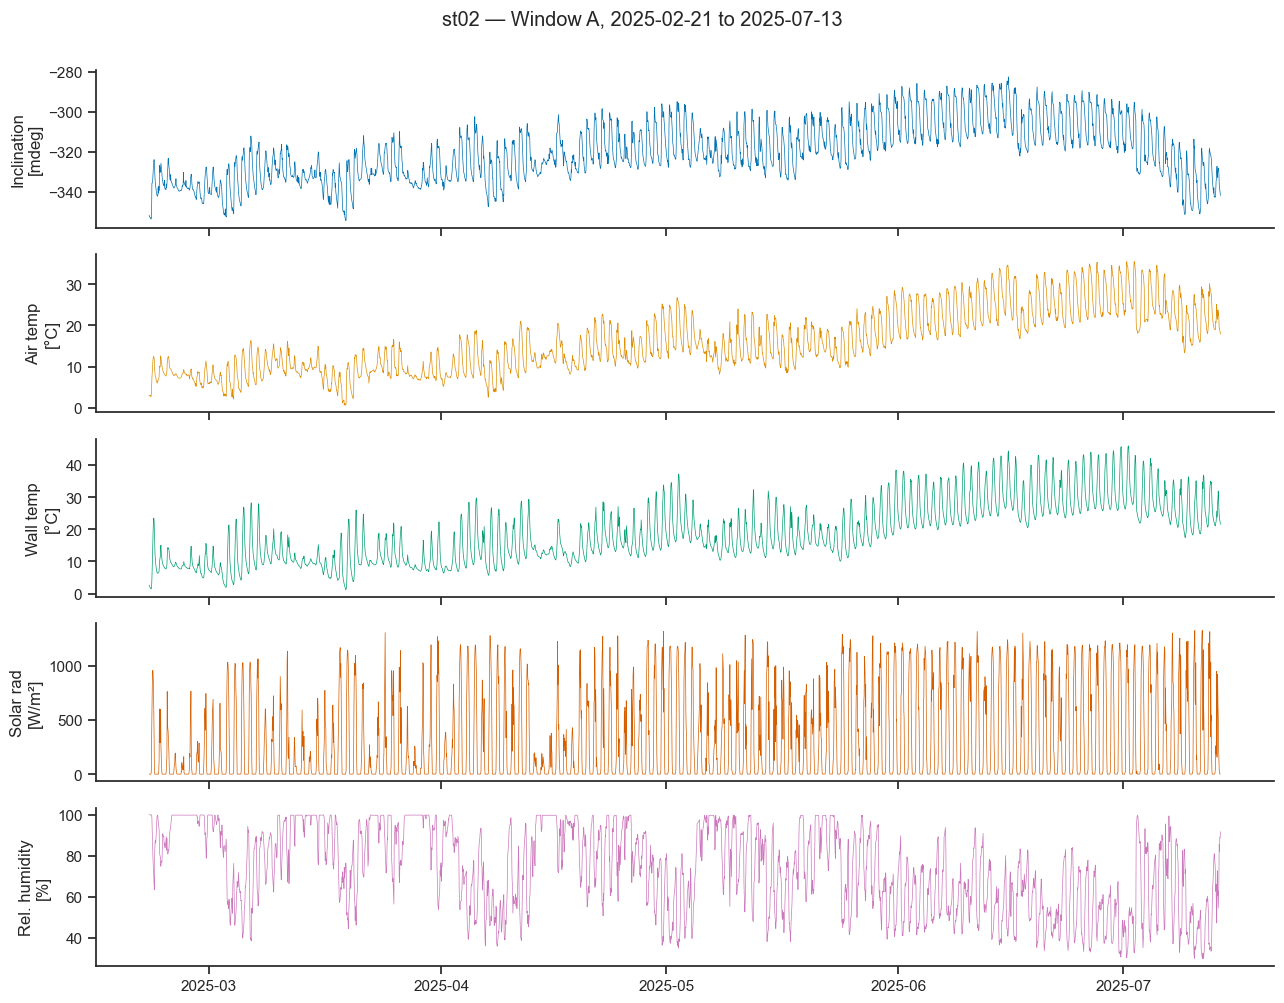

In [8]:
fig = tc.plot_overview(
    win, title=f'{STATION} — Window A, {WINDOW_A[0]} to {WINDOW_A[1]}',
    save_path=OUTPUT_DIR, filename=f'S1_02_{STATION}_overview_windowA')
plt.show()

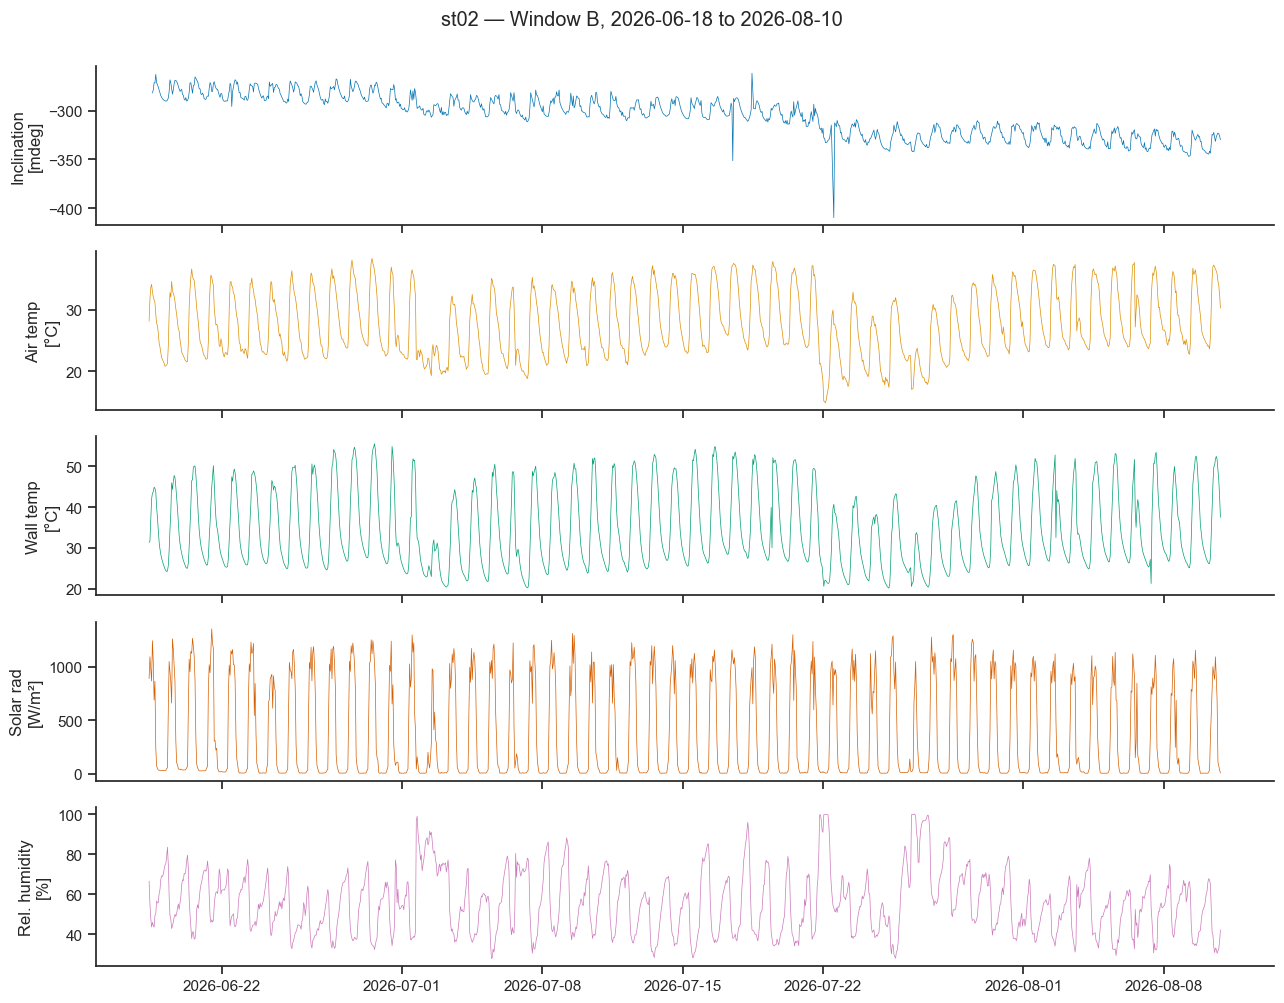

In [9]:
fig = tc.plot_overview(
    win_b, title=f'{STATION} — Window B, {WINDOW_B[0]} to {WINDOW_B[1]}',
    save_path=OUTPUT_DIR, filename=f'S1_03_{STATION}_overview_windowB')
plt.show()

## Step 4 · Diurnal structure

The standardised panel is the informative one. If the inclination follows air
temperature instantaneously, its profile should sit on top of the air-temperature
profile. Any horizontal offset is thermal inertia, and an instantaneous correction
cannot reproduce it.

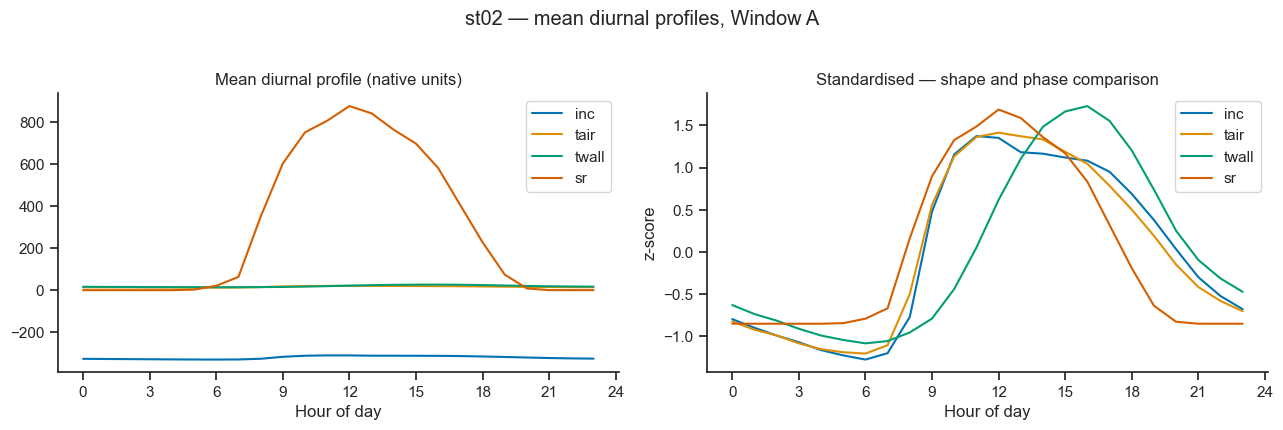

In [10]:
fig = tc.plot_diurnal(
    win, title=f'{STATION} — mean diurnal profiles, Window A',
    save_path=OUTPUT_DIR, filename=f'S1_04_{STATION}_diurnal')
plt.show()

## Step 5 · Correlation structure

Both matrices are reported. Correlations on levels between two trending series are
inflated by the shared trend; correlations on first differences describe the
driver-response relationship at the sampling scale. A large gap between the two is
itself diagnostic.

In [11]:
cols = ['inc'] + DRIVERS
lev = tc.correlation_matrix(win, cols, differenced=False)
dif = tc.correlation_matrix(win, cols, differenced=True)
spe = tc.correlation_matrix(win, cols, method='spearman', differenced=False)

print('Pearson, levels:');            display(lev.round(3))
print('Pearson, first differences:'); display(dif.round(3))
print('Spearman, levels:');           display(spe.round(3))

lev.to_csv(f'{OUTPUT_DIR}/S1_05_{STATION}_corr_levels.csv')
dif.to_csv(f'{OUTPUT_DIR}/S1_06_{STATION}_corr_differenced.csv')

Pearson, levels:


,inc,tair,twall,sr,rh
inc,1.000,0.845,0.791,0.588,-0.611
tair,0.845,1.000,0.924,0.564,-0.720
twall,0.791,0.924,1.000,0.468,-0.730
sr,0.588,0.564,0.468,1.000,-0.610
rh,-0.611,-0.720,-0.730,-0.610,1.000


Pearson, first differences:


,inc,tair,twall,sr,rh
inc,1.000,0.826,0.394,0.398,-0.673
tair,0.826,1.000,0.476,0.604,-0.800
twall,0.394,0.476,1.000,0.333,-0.431
sr,0.398,0.604,0.333,1.000,-0.445
rh,-0.673,-0.800,-0.431,-0.445,1.000


Spearman, levels:


,inc,tair,twall,sr,rh
inc,1.000,0.855,0.810,0.604,-0.624
tair,0.855,1.000,0.938,0.566,-0.708
twall,0.810,0.938,1.000,0.497,-0.732
sr,0.604,0.566,0.497,1.000,-0.537
rh,-0.624,-0.708,-0.732,-0.537,1.000


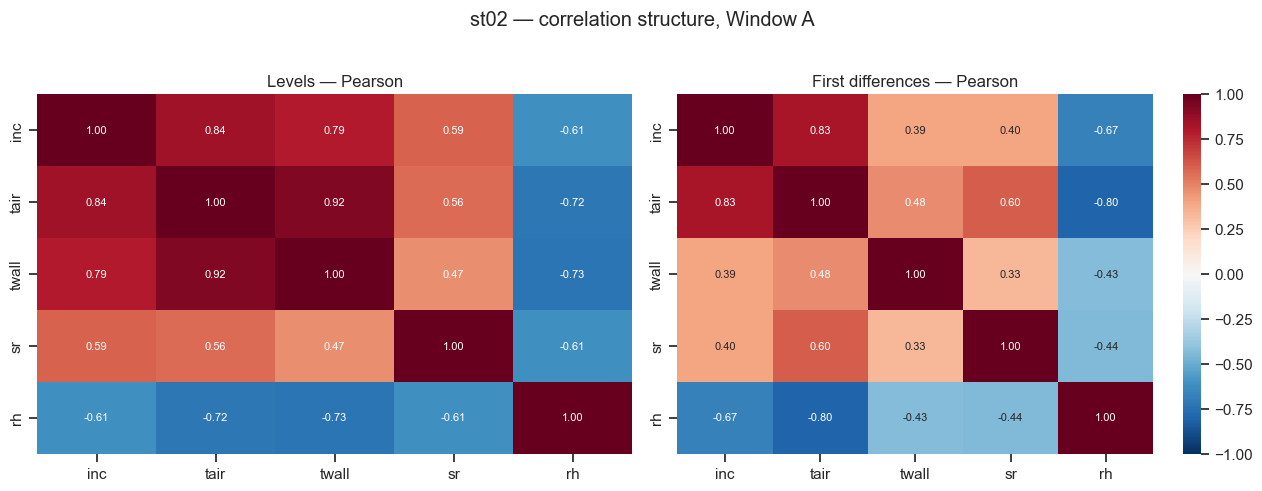

In [12]:
fig = tc.plot_correlation_heatmaps(
    win, cols, title=f'{STATION} — correlation structure, Window A',
    save_path=OUTPUT_DIR, filename=f'S1_07_{STATION}_corr_heatmaps')
plt.show()

## Step 6 · Lag structure

Cross-correlation of the signal against each driver over ±5 days, computed **twice**:
once on levels and once on first differences. A positive lead means the driver moves
first.

The two panels answer different questions, and reporting only one of them is how a
lagged response gets mistaken for an instantaneous one. Differencing is a high-pass
filter — it removes the slow component of both series by construction, so the
differenced cross-correlation describes how the signal tracks a driver from one hour
to the next and is close to blind to the response of the masonry as a bulk. The
levels cross-correlation keeps the slow component, which is where the thermal mass
lives.

In [13]:
ccf_dif = tc.cross_correlation(win, 'inc', DRIVERS, MAX_LAG_STEPS,
                               differenced=True)
ccf_lev = tc.cross_correlation(win, 'inc', DRIVERS, MAX_LAG_STEPS,
                               differenced=False)

peaks_dif = tc.peak_lags(ccf_dif, SAMPLING_HOURS)
peaks_lev = tc.peak_lags(ccf_lev, SAMPLING_HOURS,
                         match_sign=True, positive_only=True)
print('First differences:'); display(peaks_dif)
print('Levels:');            display(peaks_lev)
peaks_dif.to_csv(f'{OUTPUT_DIR}/S1_08_{STATION}_peak_lags.csv')
peaks_lev.to_csv(f'{OUTPUT_DIR}/S1_27_{STATION}_peak_lags_levels.csv')

First differences:


,peak_corr,peak_lag_steps,peak_lag_hours,corr_at_lag0
driver,,,,
tair,0.8260,0,0.0,0.8260
twall,0.4766,-3,-3.0,0.3938
sr,0.5838,1,1.0,0.3978
rh,-0.6734,0,0.0,-0.6734


Levels:


,peak_corr,peak_lag_steps,peak_lag_hours,corr_at_lag0
driver,,,,
tair,0.8446,0,0.0,0.8446
twall,0.7908,0,0.0,0.7908
sr,0.6286,1,1.0,0.5880
rh,-0.6106,0,0.0,-0.6106


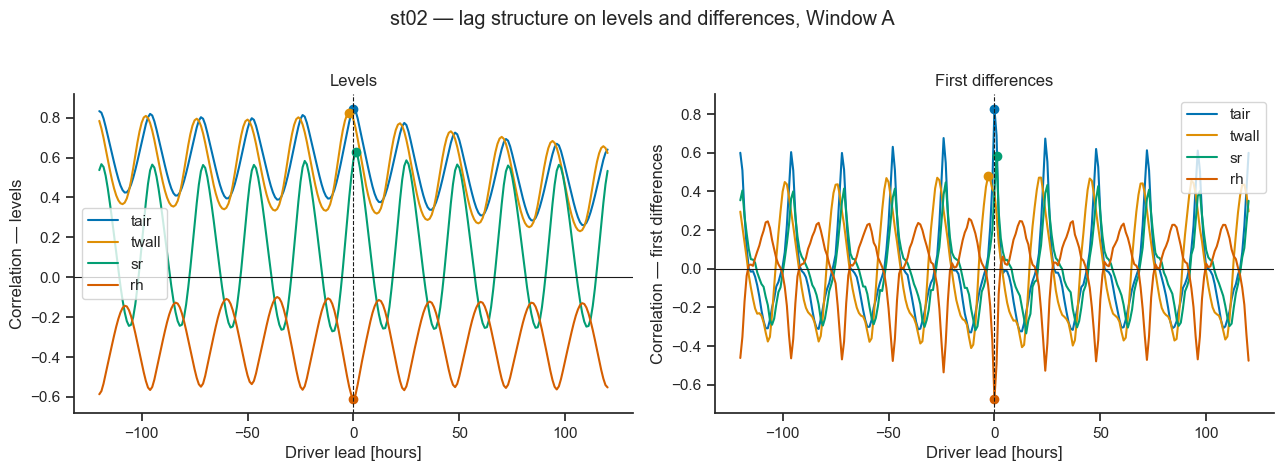

In [14]:
fig = tc.plot_lag_scan(
    ccf_lev, ccf_dif, SAMPLING_HOURS,
    title=f'{STATION} — lag structure on levels and differences, Window A',
    save_path=OUTPUT_DIR, filename=f'S1_09_{STATION}_cross_correlation')
plt.show()

### Sub-hourly check

The hourly grid cannot resolve a lag shorter than an hour. The same differenced
cross-correlation is therefore repeated once on the native 20-minute record, purely
to confirm that nothing important is hiding below the analysis resolution.

In [15]:
win_native = df_native.loc[WINDOW_A[0]:WINDOW_A[1]]
ccf_native = tc.cross_correlation(win_native, 'inc', DRIVERS,
                                  int(6 / (1 / 3)), differenced=True)
peaks_native = tc.peak_lags(ccf_native, 1 / 3)
display(peaks_native)
peaks_native.to_csv(f'{OUTPUT_DIR}/S1_28_{STATION}_peak_lags_native.csv')

,peak_corr,peak_lag_steps,peak_lag_hours,corr_at_lag0
driver,,,,
tair,0.3746,0,0.00,0.3746
twall,0.2157,-9,-3.00,0.1950
sr,0.1304,1,0.33,0.0188
rh,-0.2547,0,0.00,-0.2547


## Step 6b · Thermal inertia — how delayed is the response?

A shift is a crude model of a lagged response: it assumes the structure reproduces
the driver exactly, only later. A wall does not do that. It integrates the forcing,
so its effective temperature is a smoothed and delayed version of the driver, and the
standard first-order (lumped-capacitance) model of that behaviour is a single-pole
low-pass filter with time constant $\tau$:

$$ T_{\text{eff}}(t) = T_{\text{eff}}(t-\Delta t) + \frac{\Delta t}{\tau + \Delta t}
   \big( T_{\text{driver}}(t) - T_{\text{eff}}(t-\Delta t) \big) $$

Scanning $\tau$ and refitting at each value asks the physical question directly: what
thermal time constant, if any, makes a driver explain the signal best? $\tau = 0$ is
the instantaneous assumption, so the correction's premise is included in the scan as
a special case rather than being argued about separately.

In [16]:
scan = tc.inertia_scan(win, 'inc', DRIVERS, TAUS)
best_tau = tc.best_inertia(scan)
print('Full signal:'); display(best_tau)
scan.to_csv(f'{OUTPUT_DIR}/S1_29_{STATION}_inertia_scan.csv', index=False)
best_tau.to_csv(f'{OUTPUT_DIR}/S1_30_{STATION}_best_inertia.csv')

Full signal:


,best_tau_hours,slope_at_best,r2_at_best,r2_instantaneous,r2_gain
driver,,,,,
tair,0.0,1.6279,0.7134,0.7134,0.0000
twall,0.0,1.2476,0.6253,0.6253,0.0000
sr,4.0,0.0380,0.4597,0.3458,0.1139
rh,0.0,-0.4341,0.3728,0.3728,0.0000


**The same scan, band-limited.** Window A runs from late winter to midsummer, so its
levels are dominated by the seasonal march of temperature. A fit on that can look
excellent while saying nothing about how fast the structure answers a change in
forcing, because both series are simply drifting upward together. Repeating the scan
on the residual from a centred weekly mean removes the slow component and leaves the
diurnal band, which is where a thermal time constant of a few hours would show
itself.

In [17]:
scan_band = tc.inertia_scan(win, 'inc', DRIVERS, TAUS, detrend_hours=168)
best_tau_band = tc.best_inertia(scan_band)
print('Diurnal band (weekly mean removed):'); display(best_tau_band)
scan_band.to_csv(f'{OUTPUT_DIR}/S1_33_{STATION}_inertia_scan_band.csv',
                 index=False)
best_tau_band.to_csv(f'{OUTPUT_DIR}/S1_34_{STATION}_best_inertia_band.csv')

Diurnal band (weekly mean removed):


,best_tau_hours,slope_at_best,r2_at_best,r2_instantaneous,r2_gain
driver,,,,,
tair,0.0,2.2909,0.9323,0.9323,0.0000
twall,0.0,1.3185,0.5881,0.5881,0.0000
sr,2.0,0.0245,0.7313,0.5751,0.1562
rh,0.0,-0.4304,0.4839,0.4839,0.0000


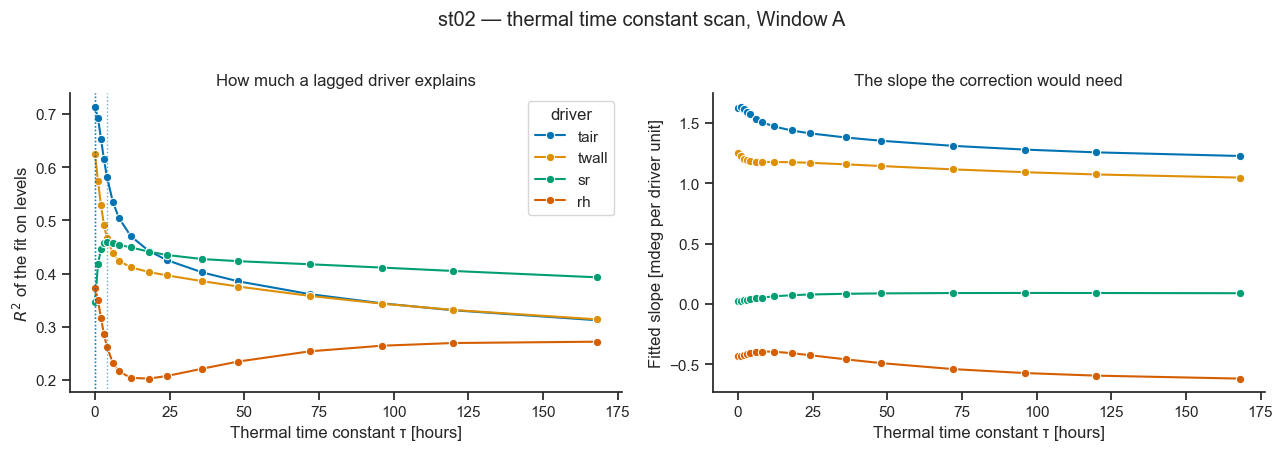

In [18]:
fig = tc.plot_inertia_scan(
    scan, title=f'{STATION} — thermal time constant scan, Window A',
    save_path=OUTPUT_DIR, filename=f'S1_31_{STATION}_inertia_scan')
plt.show()

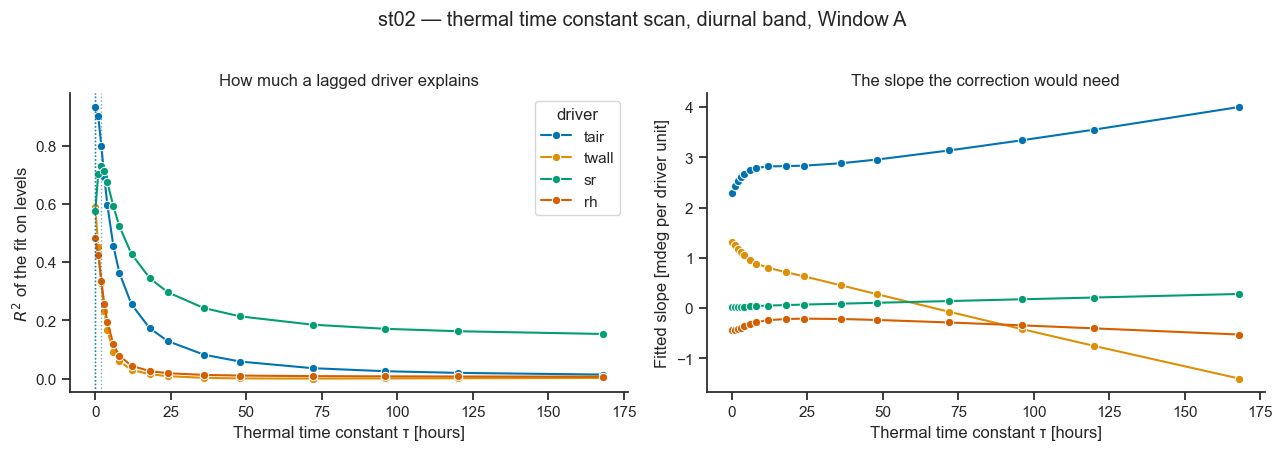

In [19]:
fig = tc.plot_inertia_scan(
    scan_band,
    title=f'{STATION} — thermal time constant scan, diurnal band, Window A',
    save_path=OUTPUT_DIR, filename=f'S1_35_{STATION}_inertia_scan_band')
plt.show()

The number that matters is `r2_gain`: how much explanatory power is bought by
allowing the driver to act through a thermal mass instead of instantaneously. A gain
of essentially zero would vindicate the instantaneous assumption at that timescale.
Anything else falsifies it, and the winning $\tau$ is then a physical property of the
wall rather than a fitting convenience. The two scans can disagree, and if they do
that is the finding: it means no single instantaneous coefficient can serve both the
daily and the seasonal response.

## Step 7 · How large is the thermal response really?

Each driver is regressed on the signal one at a time, with
heteroskedasticity- and autocorrelation-consistent standard errors. The number to
compare against is **5.0 mdeg/°C**, the slope implied by the documented
coefficient.

In [20]:
slopes_lev = tc.slope_table(win, 'inc', DRIVERS, differenced=False)
slopes_dif = tc.slope_table(win, 'inc', DRIVERS, differenced=True)

print(f'Documented coefficient implies {tc.DOCUMENTED_COEFF * 1000:.1f} mdeg per °C\n')
print('Levels:');            display(slopes_lev)
print('First differences:'); display(slopes_dif)

slopes_lev.to_csv(f'{OUTPUT_DIR}/S1_10_{STATION}_slopes_levels.csv')
slopes_dif.to_csv(f'{OUTPUT_DIR}/S1_11_{STATION}_slopes_differenced.csv')

Documented coefficient implies 5.0 mdeg per °C

Levels:


,slope,ci_low,ci_high,se,r2,n
driver,,,,,,
tair,1.6279,1.4854,1.7705,0.0727,0.7134,3419
twall,1.2476,1.1443,1.3508,0.0527,0.6253,3419
sr,0.0214,0.0201,0.0227,0.0007,0.3458,3415
rh,-0.4341,-0.5111,-0.3571,0.0393,0.3728,3419


First differences:


,slope,ci_low,ci_high,se,r2,n
driver,,,,,,
tair,2.1730,2.0927,2.2533,0.0410,0.6823,3414
twall,0.8394,0.7821,0.8967,0.0292,0.1551,3414
sr,0.0075,0.0066,0.0084,0.0005,0.1582,3407
rh,-0.4544,-0.4838,-0.4249,0.0150,0.4535,3414


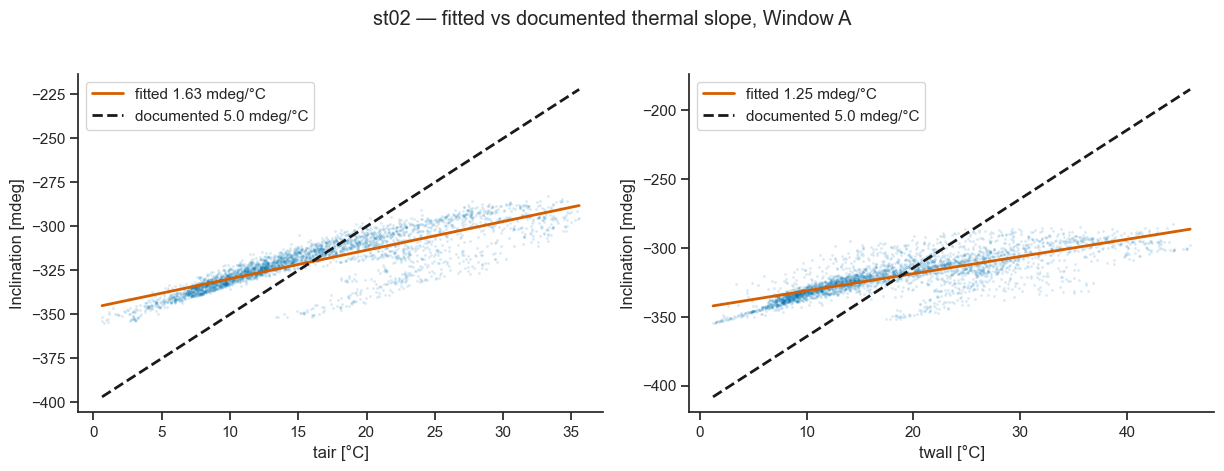

In [21]:
fig = tc.plot_thermal_scatter(
    win, temp_cols=('tair', 'twall'),
    title=f'{STATION} — fitted vs documented thermal slope, Window A',
    save_path=OUTPUT_DIR, filename=f'S1_12_{STATION}_thermal_scatter')
plt.show()

### Do the drivers compete?

Air temperature is the variable the correction uses. This checks whether it is
still the dominant explanatory variable once wall temperature and solar radiation
are allowed into the same regression.

In [22]:
mv = tc.multivariate_fit(win, 'inc', DRIVERS)
print(mv.summary().tables[1])
print(f'\nR-squared: {mv.rsquared:.4f}   n = {int(mv.nobs)}')

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -352.8801      4.749    -74.311      0.000    -362.187    -343.573
tair           1.1989      0.134      8.954      0.000       0.936       1.461
twall          0.3079      0.069      4.438      0.000       0.172       0.444
sr             0.0077      0.001      7.308      0.000       0.006       0.010
rh             0.0767      0.045      1.686      0.092      -0.012       0.166

R-squared: 0.7376   n = 3415


## Step 8 · Acceptance tests for the compensation

The correction claims to remove the thermal component of the signal. That claim is
falsifiable in three ways: the variance should fall, the correlation with
temperature should move towards zero, and the daily swing should shrink. Each is
checked below.

In [23]:
term  = tc.compensation_term(win, temp_col=TEMP_COL, coeff=tc.DOCUMENTED_COEFF)
unnorm = win['inc'] - term
shift  = unnorm.dropna().iloc[0]

win['comp_term']  = term
win['comp_shift'] = shift
win['inc_comp']   = unnorm - shift

# The reconstruction must be exact, otherwise the prediction experiment below is
# not comparing like with like.
recon = win['inc_comp'] + win['comp_term'] + win['comp_shift']
assert np.nanmax(np.abs(recon - win['inc'])) < 1e-9, 'compensation is not invertible'
print('Compensation is exactly invertible — raw-scale scoring is valid.')

Compensation is exactly invertible — raw-scale scoring is valid.


In [24]:
tests = tc.compensation_tests(win, win['inc_comp'])
display(tests)
tests.to_csv(f'{OUTPUT_DIR}/S1_13_{STATION}_acceptance_tests.csv')

,raw,compensated,target,change_%,verdict
test,,,,,
variance [mdeg^2],211.9010,709.3380,lower,234.7,WORSE
std [mdeg],14.5570,26.6330,lower,83.0,WORSE
mean diurnal amplitude [mdeg],23.5200,26.9460,lower,14.6,WORSE
|corr| with tair (levels),0.8446,0.9562,lower,13.2,WORSE
|corr| with tair (differenced),0.8260,0.8856,lower,7.2,WORSE
|corr| with twall (levels),0.7908,0.8781,lower,11.0,WORSE
|corr| with twall (differenced),0.3938,0.4266,lower,8.3,WORSE
|corr| with sr (levels),0.5880,0.4784,lower,-18.6,improved
|corr| with sr (differenced),0.3978,0.6237,lower,56.8,WORSE


A correlation that changes sign means the correction has overshot: it removed more
than the thermal component and injected an inverted copy of the temperature signal.
Absolute values hide this, so the signed comparison is reported separately.

In [25]:
signs = tc.signed_correlation_check(win, win['inc_comp'])
display(signs)
signs.to_csv(f'{OUTPUT_DIR}/S1_14_{STATION}_signed_correlations.csv')

,corr_raw,corr_compensated,sign_flipped,overcorrected
driver,,,,
tair,0.8446,-0.9562,True,True
twall,0.7908,-0.8781,True,True
sr,0.5880,-0.4784,True,True


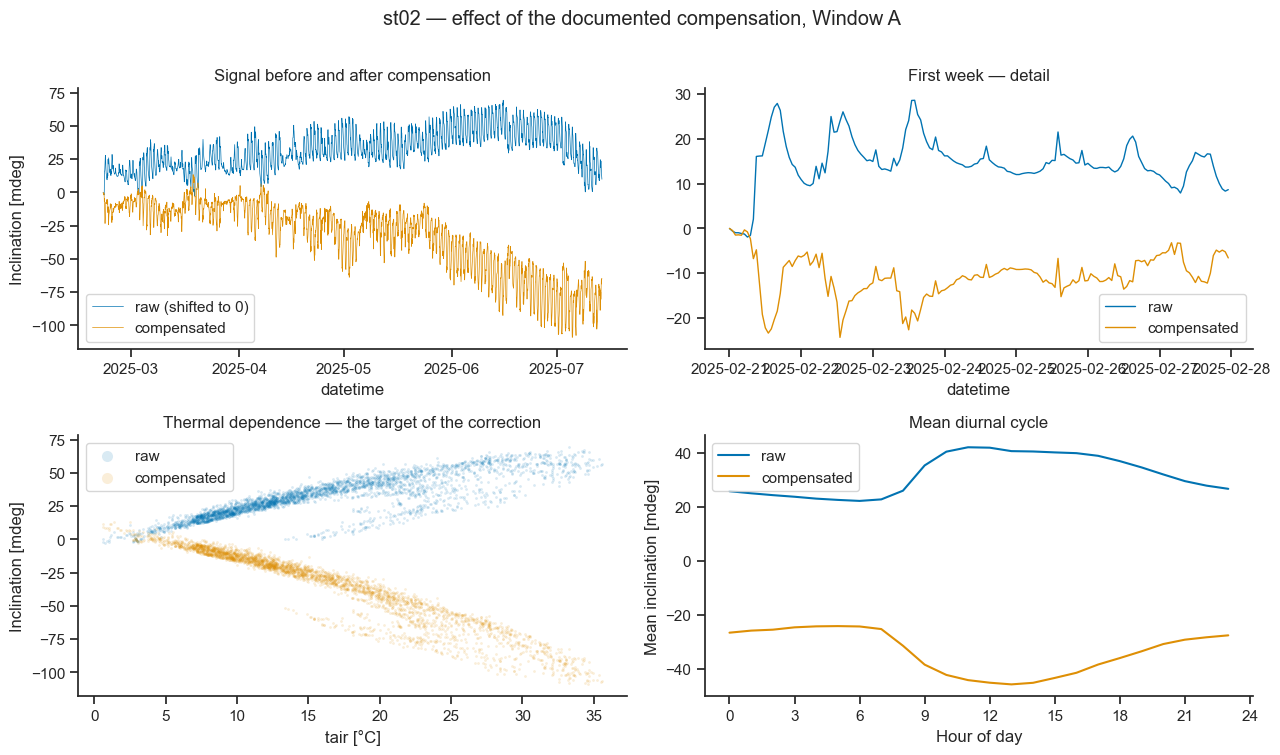

In [26]:
fig = tc.plot_compensation_effect(
    win, win['inc_comp'], temp_col=TEMP_COL,
    title=f'{STATION} — effect of the documented compensation, Window A',
    save_path=OUTPUT_DIR, filename=f'S1_15_{STATION}_compensation_effect')
plt.show()

## Step 9 · Where does the documented coefficient sit?

Sweeping the coefficient shows the value that would actually minimise residual
variance, and how far the documented 0.005 is from it. A documented value on the
wrong side of the minimum is not merely suboptimal — it makes the series worse than
leaving it alone.

In [27]:
sweep = tc.coefficient_sweep(win, temp_col=TEMP_COL)
best  = sweep.loc[sweep['residual_var'].idxmin()]
zero  = sweep.loc[(sweep['coeff'] - 0).abs().idxmin()]
docv  = sweep.loc[(sweep['coeff'] - tc.DOCUMENTED_COEFF).abs().idxmin()]

print(f"variance-minimising : {best['mdeg_per_degC']:7.3f} mdeg/°C  "
      f"residual var {best['residual_var']:.2f}")
print(f"no compensation     : {zero['mdeg_per_degC']:7.3f} mdeg/°C  "
      f"residual var {zero['residual_var']:.2f}")
print(f"documented          : {docv['mdeg_per_degC']:7.3f} mdeg/°C  "
      f"residual var {docv['residual_var']:.2f}")
sweep.to_csv(f'{OUTPUT_DIR}/S1_16_{STATION}_coefficient_sweep.csv', index=False)

variance-minimising :   1.600 mdeg/°C  residual var 60.77
no compensation     :   0.000 mdeg/°C  residual var 211.90
documented          :   5.000 mdeg/°C  residual var 709.34


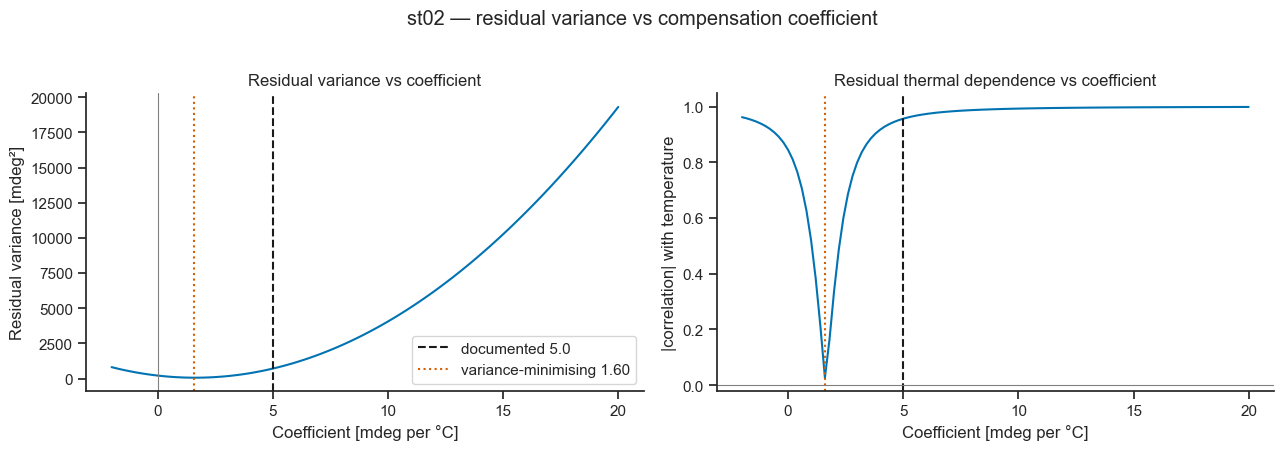

In [28]:
fig = tc.plot_coefficient_sweep(
    sweep, title=f'{STATION} — residual variance vs compensation coefficient',
    save_path=OUTPUT_DIR, filename=f'S1_17_{STATION}_coefficient_sweep')
plt.show()

## Step 10 · The prediction experiment

The four configurations described at the top. Every one is scored on the **raw
signal scale**: predictions of the compensated target have the correction added
back before the error is computed. Without that step the comparison would be
meaningless, because the compensated and raw targets have different variances and
a smaller MAE could be bought simply by predicting a flatter series.

The split is chronological. The model never sees data from after the point at which
it is scored.

**Which contrast answers the question.** Window A runs from late February to
mid-July, so its temperature rises monotonically across the record and the test
period sits largely outside the training temperature range. Any configuration that
leans on temperature must therefore extrapolate, and comparisons *between*
regressor sets are partly a measure of that extrapolation rather than of the
preprocessing.

The controlled contrast is therefore **C against D**. Both use the same model form
with no exogenous regressors; they differ in one respect only — whether the target
was compensated first. That pair isolates the effect of the correction. The A-versus-D
comparison is reported alongside because it is informative in its own right, but it
answers a different question.

**Two further configurations test the physics.** Configuration E supplies each driver
shifted to the lag that maximised its cross-correlation on levels; configuration F
supplies each driver filtered through its best-fitting thermal time constant. Both are
built from quantities measured in Step 6, and both are applied to the *raw* target, so
they compete against A and D rather than against the correction.

In [29]:
THERMAL = ['tair', 'twall', 'sr']

lag_spec = {c: int(round(peaks_lev.loc[c, 'peak_lag_hours'] / SAMPLING_HOURS))
            for c in THERMAL}

# F takes its time constants from the band-limited scan rather than the full
# signal. The forecasting models below carry their own trend and seasonal terms,
# so what an exogenous regressor has to supply is the fast response, and the
# band-limited scan is the estimate of exactly that. Where the band-limited
# optimum is zero the configuration degenerates towards A, which is itself a
# reportable outcome rather than a problem.
tau_spec = {c: float(best_tau_band.loc[c, 'best_tau_hours']) for c in THERMAL}
print('lags  [steps]:', lag_spec)
print('taus  [hours]:', tau_spec)

for frame in (win, win_b):
    tc.add_lagged(frame, lag_spec)
    tc.add_inertia(frame, tau_spec)
LAGGED   = [f'{c}_lag{lag_spec[c]}' for c in THERMAL]
INERTIAL = [f'{c}_tau{int(round(tau_spec[c]))}' for c in THERMAL]

lags  [steps]: {'tair': 0, 'twall': 0, 'sr': 1}
taus  [hours]: {'tair': 0.0, 'twall': 0.0, 'sr': 2.0}


In [30]:
CONFIGS = {
    'A · raw + thermal regressors': {
        'target': 'inc', 'regressors': THERMAL,
        'add_back': False},
    'B · compensated + thermal regressors': {
        'target': 'inc_comp', 'regressors': THERMAL,
        'add_back': True},
    'C · compensated, no thermal regressors': {
        'target': 'inc_comp', 'regressors': [],
        'add_back': True},
    'D · raw, no thermal regressors': {
        'target': 'inc', 'regressors': [],
        'add_back': False},
    'E · raw + lag-optimised regressors': {
        'target': 'inc', 'regressors': LAGGED,
        'add_back': False},
    'F · raw + thermal-inertia regressors': {
        'target': 'inc', 'regressors': INERTIAL,
        'add_back': False},
}

### One step ahead (one hour)

In [31]:
res_1, preds_1 = tc.run_ridge_experiment(
    win, CONFIGS, n_lags=N_LAGS_MODEL, horizon=1, train_frac=TRAIN_FRAC)
display(res_1)
res_1.to_csv(f'{OUTPUT_DIR}/S1_18_{STATION}_ridge_h1.csv')

,target,regressors,n_train,n_test,MAE_mdeg,RMSE_mdeg,MAE_vs_best_%
config,,,,,,,
A · raw + thermal regressors,inc,"tair, twall, sr",2348,1007,6.5422,8.0476,239.93
B · compensated + thermal regressors,inc_comp,"tair, twall, sr",2348,1007,7.0425,8.4657,265.92
"C · compensated, no thermal regressors",inc_comp,none,2351,1008,3.3075,5.0805,71.85
"D · raw, no thermal regressors",inc,none,2351,1008,1.9246,3.0875,0.00
E · raw + lag-optimised regressors,inc,"tair_lag0, twall_lag0, sr_lag1",2348,1007,6.8648,8.4968,256.69
F · raw + thermal-inertia regressors,inc,"tair_tau0, twall_tau0, sr_tau2",2348,1007,6.8054,8.4610,253.60


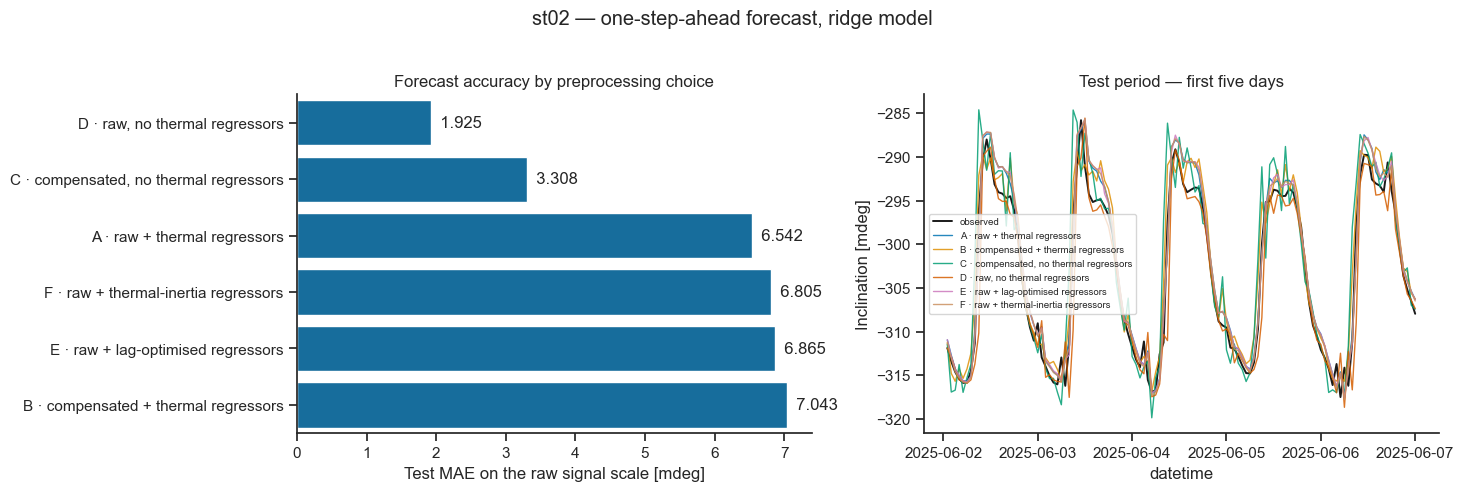

In [32]:
fig = tc.plot_experiment(
    res_1, preds_1, win['inc'],
    title=f'{STATION} — one-step-ahead forecast, ridge model',
    save_path=OUTPUT_DIR, filename=f'S1_19_{STATION}_experiment_h1')
plt.show()

### Twenty-four hours ahead

The one-step problem is dominated by autocorrelation, which can mask the effect of
preprocessing. At a 24-hour horizon the autoregressive term is far weaker and the
treatment of the thermal response matters much more.

In [33]:
res_24, preds_24 = tc.run_ridge_experiment(
    win, CONFIGS, n_lags=N_LAGS_MODEL, horizon=HORIZON_LONG, train_frac=TRAIN_FRAC)
display(res_24)
res_24.to_csv(f'{OUTPUT_DIR}/S1_20_{STATION}_ridge_h24.csv')

,target,regressors,n_train,n_test,MAE_mdeg,RMSE_mdeg,MAE_vs_best_%
config,,,,,,,
A · raw + thermal regressors,inc,"tair, twall, sr",2326,997,14.1391,16.8804,288.50
B · compensated + thermal regressors,inc_comp,"tair, twall, sr",2326,997,13.1930,16.1338,262.50
"C · compensated, no thermal regressors",inc_comp,none,2328,999,7.6349,9.2839,109.78
"D · raw, no thermal regressors",inc,none,2328,999,3.6394,5.0113,0.00
E · raw + lag-optimised regressors,inc,"tair_lag0, twall_lag0, sr_lag1",2324,996,13.5486,16.2908,272.28
F · raw + thermal-inertia regressors,inc,"tair_tau0, twall_tau0, sr_tau2",2326,997,13.3373,16.1089,266.47


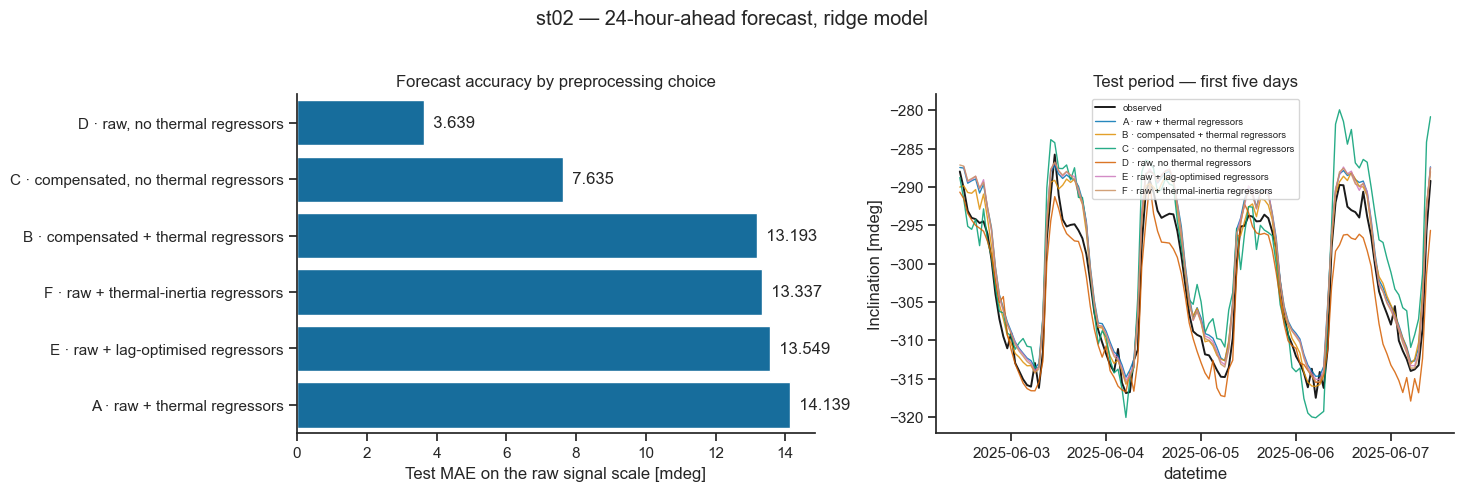

In [34]:
fig = tc.plot_experiment(
    res_24, preds_24, win['inc'],
    title=f'{STATION} — 24-hour-ahead forecast, ridge model',
    save_path=OUTPUT_DIR, filename=f'S1_21_{STATION}_experiment_h24')
plt.show()

### Out-of-period check on Window B

Window B sits eleven months after Window A, in a different season, on the far side
of a 103-day outage. If the ordering of the configurations holds here as well, it
is not an artefact of one period.

In [35]:
term_b = tc.compensation_term(win_b, temp_col=TEMP_COL, coeff=tc.DOCUMENTED_COEFF)
unnorm_b = win_b['inc'] - term_b
win_b['comp_term']  = term_b
win_b['comp_shift'] = unnorm_b.dropna().iloc[0]
win_b['inc_comp']   = unnorm_b - unnorm_b.dropna().iloc[0]

res_b, preds_b = tc.run_ridge_experiment(
    win_b, CONFIGS, n_lags=N_LAGS_MODEL, horizon=HORIZON_LONG, train_frac=TRAIN_FRAC)
display(res_b)
res_b.to_csv(f'{OUTPUT_DIR}/S1_22_{STATION}_ridge_h24_windowB.csv')

,target,regressors,n_train,n_test,MAE_mdeg,RMSE_mdeg,MAE_vs_best_%
config,,,,,,,
A · raw + thermal regressors,inc,"tair, twall, sr",525,225,5.7027,6.5291,71.16
B · compensated + thermal regressors,inc_comp,"tair, twall, sr",525,225,5.9197,7.2911,77.67
"C · compensated, no thermal regressors",inc_comp,none,525,225,7.3078,9.3234,119.33
"D · raw, no thermal regressors",inc,none,525,225,3.3318,4.2758,0.00
E · raw + lag-optimised regressors,inc,"tair_lag0, twall_lag0, sr_lag1",524,225,5.0081,5.9162,50.31
F · raw + thermal-inertia regressors,inc,"tair_tau0, twall_tau0, sr_tau2",525,225,5.2299,6.0995,56.97


### The controlled contrast, collected

C against D across every horizon and both windows. Positive means the compensated
target was harder to forecast than the raw one.

In [36]:
KEY_C = 'C · compensated, no thermal regressors'
KEY_D = 'D · raw, no thermal regressors'
KEY_A = 'A · raw + thermal regressors'

res_b1, _ = tc.run_ridge_experiment(
    win_b, CONFIGS, n_lags=N_LAGS_MODEL, horizon=1, train_frac=TRAIN_FRAC)

contrast = pd.DataFrame([
    {'window': 'A', 'horizon': '1 h', 'res': res_1},
    {'window': 'A', 'horizon': '24 h',   'res': res_24},
    {'window': 'B', 'horizon': '1 h', 'res': res_b1},
    {'window': 'B', 'horizon': '24 h',   'res': res_b},
])
rows = []
for _, r in contrast.iterrows():
    t = r['res']
    rows.append({
        'window': r['window'],
        'horizon': r['horizon'],
        'MAE raw (D)': t.loc[KEY_D, 'MAE_mdeg'],
        'MAE compensated (C)': t.loc[KEY_C, 'MAE_mdeg'],
        'compensation penalty %': round(
            100 * (t.loc[KEY_C, 'MAE_mdeg'] - t.loc[KEY_D, 'MAE_mdeg'])
            / t.loc[KEY_D, 'MAE_mdeg'], 1),
        'MAE raw+regressors (A)': t.loc[KEY_A, 'MAE_mdeg'],
    })
contrast_table = pd.DataFrame(rows)
display(contrast_table)
contrast_table.to_csv(f'{OUTPUT_DIR}/S1_26_{STATION}_controlled_contrast.csv',
                      index=False)

,window,horizon,MAE raw (D),MAE compensated (C),compensation penalty %,MAE raw+regressors (A)
0,A,1 h,1.9246,3.3075,71.9,6.5422
1,A,24 h,3.6394,7.6349,109.8,14.1391
2,B,1 h,3.5475,5.9657,68.2,3.4926
3,B,24 h,3.3318,7.3078,119.3,5.7027


## Step 11 · Confirmation under NeuralProphet

The ridge model establishes the ordering cheaply and transparently. This repeats it
under the model the project actually deploys, whose autoregressive and seasonal
terms interact with the preprocessing choice in ways a linear model cannot show.

In [37]:
if RUN_NEURALPROPHET:
    res_np = tc.run_neuralprophet_experiment(
        win, CONFIGS, freq=ANALYSIS_FREQ, train_frac=TRAIN_FRAC,
        n_lags=NP_LAGS, epochs=NP_EPOCHS, horizon=1)
    display(res_np)
    res_np.to_csv(f'{OUTPUT_DIR}/S1_23_{STATION}_neuralprophet_h1.csv')
else:
    res_np = None
    print('NeuralProphet confirmation skipped (RUN_NEURALPROPHET = False).')

Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


,target,regressors,n_test,MAE_mdeg,RMSE_mdeg,MAE_vs_best_%
config,,,,,,
A · raw + thermal regressors,inc,"tair, twall, sr",1030,2.2249,2.9124,0.00
B · compensated + thermal regressors,inc_comp,"tair, twall, sr",1030,4.3028,5.8329,93.39
"C · compensated, no thermal regressors",inc_comp,none,1030,3.8803,5.3965,74.40
"D · raw, no thermal regressors",inc,none,1030,2.2381,2.9696,0.59
E · raw + lag-optimised regressors,inc,"tair_lag0, twall_lag0, sr_lag1",1030,2.2259,2.9099,0.04
F · raw + thermal-inertia regressors,inc,"tair_tau0, twall_tau0, sr_tau2",1030,2.3124,3.0282,3.93


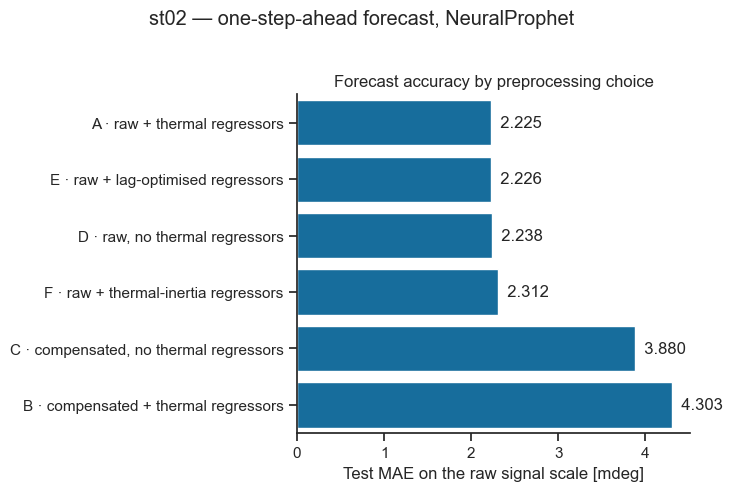

In [38]:
if res_np is not None and len(res_np):
    fig = tc.plot_experiment(
        res_np, title=f'{STATION} — one-step-ahead forecast, NeuralProphet',
        save_path=OUTPUT_DIR, filename=f'S1_24_{STATION}_experiment_neuralprophet')
    plt.show()

## Step 12 · Verdict

The cells below restate the three decision criteria and evaluate each against the
numbers produced above, so that the conclusion is derived rather than asserted.

In [39]:
lines = []

# Criterion 1 — does the correction remove thermal dependence?
r_raw = abs(win['inc'].corr(win[TEMP_COL]))
r_cmp = abs(win['inc_comp'].corr(win[TEMP_COL]))
c1 = r_cmp < r_raw
lines.append(f"1. Thermal dependence on {TEMP_COL}: "
             f"|r| {r_raw:.3f} -> {r_cmp:.3f}  "
             f"[{'REDUCED' if c1 else 'NOT REDUCED'}]")

# Criterion 2 — is the coefficient anywhere near the variance-minimising value?
c2 = abs(docv['mdeg_per_degC'] - best['mdeg_per_degC']) <= 1.0
lines.append(f"2. Coefficient: documented {docv['mdeg_per_degC']:.2f} vs "
             f"variance-minimising {best['mdeg_per_degC']:.2f} mdeg/°C  "
             f"[{'CLOSE' if c2 else 'FAR'}]")

# Criterion 3 — the controlled contrast: does compensating the target help a
# forecast, holding the model form fixed? Required to hold at every horizon and
# in both windows, otherwise it is a period-specific accident.
c3 = bool((contrast_table['compensation penalty %'] <= 0).all())
worst = contrast_table['compensation penalty %'].max()
best_pen = contrast_table['compensation penalty %'].min()
lines.append(f"3. Forecast, compensated (C) vs raw (D), same model form: "
             f"penalty ranges {best_pen:+.1f} % to {worst:+.1f} % across "
             f"4 window/horizon combinations  "
             f"[{'COMPENSATION HELPS' if c3 else 'COMPENSATION HURTS'}]")

print('\n'.join(lines))
print()
print('Overall:', 'KEEP the compensation' if (c1 and c2 and c3)
      else 'DROP the fixed compensation and let the model estimate the '
           'thermal response')

1. Thermal dependence on tair: |r| 0.845 -> 0.956  [NOT REDUCED]
2. Coefficient: documented 5.00 vs variance-minimising 1.60 mdeg/°C  [FAR]
3. Forecast, compensated (C) vs raw (D), same model form: penalty ranges +68.2 % to +119.3 % across 4 window/horizon combinations  [COMPENSATION HURTS]

Overall: DROP the fixed compensation and let the model estimate the thermal response


In [40]:
summary = pd.DataFrame({
    'criterion': ['thermal dependence reduced',
                  'coefficient near variance-minimising',
                  'improves forecast (controlled contrast)'],
    'passed': [bool(c1), bool(c2), bool(c3)],
})
display(summary)
summary.to_csv(f'{OUTPUT_DIR}/S1_25_{STATION}_verdict.csv', index=False)

,criterion,passed
0,thermal dependence reduced,False
1,coefficient near variance-minimising,False
2,improves forecast (controlled contrast),False


## Step 13 · Is the response instantaneous?

A separate question from the verdict above, and the one that decides how the thermal
response should be modelled once the fixed correction is gone. Three independent
pieces of evidence are collected: the lag at which each driver peaks on levels, the
explanatory gain from allowing a thermal time constant, and whether the lagged and
inertia-filtered configurations beat the instantaneous one in the forecast.

In [41]:
KEY_E = 'E · raw + lag-optimised regressors'
KEY_F = 'F · raw + thermal-inertia regressors'

lag_lines = []
for d in THERMAL:
    lag_lines.append(
        f"  {d:<6} peak on levels {peaks_lev.loc[d, 'peak_lag_hours']:+5.1f} h "
        f"| full-signal tau {best_tau.loc[d, 'best_tau_hours']:5.1f} h "
        f"(R2 gain {best_tau.loc[d, 'r2_gain']:+.3f}) "
        f"| diurnal-band tau {best_tau_band.loc[d, 'best_tau_hours']:5.1f} h "
        f"(R2 {best_tau_band.loc[d, 'r2_instantaneous']:.3f} -> "
        f"{best_tau_band.loc[d, 'r2_at_best']:.3f}, "
        f"gain {best_tau_band.loc[d, 'r2_gain']:+.3f})")

inst = res_24.loc[KEY_A, 'MAE_mdeg']
gains = {k: round(100 * (inst - res_24.loc[k, 'MAE_mdeg']) / inst, 1)
         for k in (KEY_E, KEY_F) if k in res_24.index}

print('Driver lag and inertia, Window A:')
print('\n'.join(lag_lines))
print(f'\n24-hour forecast, MAE against the instantaneous regressors (A = '
      f'{inst:.3f} mdeg):')
for k, g in gains.items():
    print(f'  {k}: {res_24.loc[k, "MAE_mdeg"]:.3f} mdeg  ({g:+.1f} % better)')

instantaneous_ok = bool(
    (best_tau['r2_gain'].max() < 0.01) and
    (best_tau_band['r2_gain'].max() < 0.01) and
    (max(gains.values()) <= 0 if gains else True))
print(f'\nInstantaneous assumption: '
      f'{"SUPPORTED" if instantaneous_ok else "REJECTED"}')

Driver lag and inertia, Window A:
  tair   peak on levels  +0.0 h | full-signal tau   0.0 h (R2 gain +0.000) | diurnal-band tau   0.0 h (R2 0.932 -> 0.932, gain +0.000)
  twall  peak on levels  +0.0 h | full-signal tau   0.0 h (R2 gain +0.000) | diurnal-band tau   0.0 h (R2 0.588 -> 0.588, gain +0.000)
  sr     peak on levels  +1.0 h | full-signal tau   4.0 h (R2 gain +0.114) | diurnal-band tau   2.0 h (R2 0.575 -> 0.731, gain +0.156)

24-hour forecast, MAE against the instantaneous regressors (A = 14.139 mdeg):
  E · raw + lag-optimised regressors: 13.549 mdeg  (+4.2 % better)
  F · raw + thermal-inertia regressors: 13.337 mdeg  (+5.7 % better)

Instantaneous assumption: REJECTED


In [42]:
lag_summary = pd.DataFrame({
    'peak_lag_hours_levels': peaks_lev['peak_lag_hours'],
    'peak_lag_hours_differenced': peaks_dif['peak_lag_hours'],
    'tau_full_signal': best_tau['best_tau_hours'],
    'r2_gain_full_signal': best_tau['r2_gain'],
    'tau_diurnal_band': best_tau_band['best_tau_hours'],
    'r2_instantaneous_band': best_tau_band['r2_instantaneous'],
    'r2_at_best_band': best_tau_band['r2_at_best'],
    'r2_gain_band': best_tau_band['r2_gain'],
})
display(lag_summary)
lag_summary.to_csv(f'{OUTPUT_DIR}/S1_32_{STATION}_lag_summary.csv')

,peak_lag_hours_levels,peak_lag_hours_differenced,tau_full_signal,r2_gain_full_signal,tau_diurnal_band,r2_instantaneous_band,r2_at_best_band,r2_gain_band
driver,,,,,,,,
tair,0.0,0.0,0.0,0.0000,0.0,0.9323,0.9323,0.0000
twall,0.0,-3.0,0.0,0.0000,0.0,0.5881,0.5881,0.0000
sr,1.0,1.0,4.0,0.1139,2.0,0.5751,0.7313,0.1562
rh,0.0,0.0,0.0,0.0000,0.0,0.4839,0.4839,0.0000
